In [1]:
import numpy as np
import os
import sys
import matplotlib.pyplot as plt

# Navigate to the parent directory of the project structure
project_dir = os.path.abspath(os.path.join(os.getcwd(), '../..'))
src_dir = os.path.join(project_dir, 'src')
log_dir = os.path.join(project_dir, 'log')
fig_dir = os.path.join(project_dir, 'fig')
# data_dir = os.path.join(project_dir, 'build')
data_dir = os.path.join('/home/wei402/Desktop/wei402_scratch/are_data', 'build')
scripts_dir = os.path.join(project_dir, 'scripts')
os.makedirs(fig_dir, exist_ok=True)
os.makedirs(log_dir, exist_ok=True)
os.makedirs(data_dir, exist_ok=True)

# Add the src directory to sys.path
sys.path.append(src_dir)

from boolean_circuit.utils import compute_circuit_cost

Script execution time with NPARTS=32 and circuit name=tree_mech: 2.4262242317199707 seconds
Script execution time with NPARTS=64 and circuit name=tree_mech: 6.082182884216309 seconds
Script execution time with NPARTS=128 and circuit name=tree_mech: 12.679546594619751 seconds
Saved figure to /home/wei402/Desktop/shuffle-DP-protocols/fig/tree_mechanism_cost_vs_nparts_D1.png


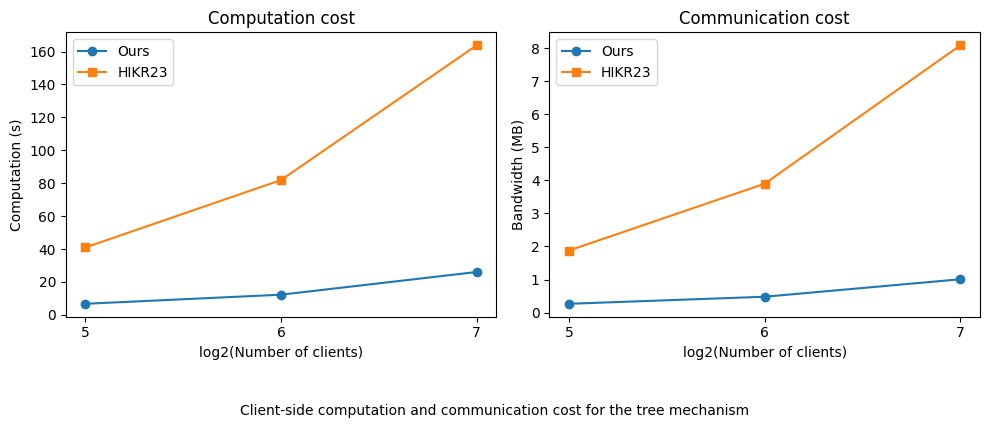

In [2]:
def plot_tree_mech_costs(nparts_list, vec_dim, fig_dir):
    """Compute tree mechanism cost stats for each NPARTS and save a comparison figure.

    Returns (fig, out_path, results) where results is a dict with arrays.
    """
    client_comp_vals = []
    baseline_comp_vals = []
    client_comm_vals = []
    baseline_comm_vals = []
    circuit_name = "tree_mech"

    for NPARTS in nparts_list:
        circut_args = {
            "NPARTS": NPARTS,
            "circuit_name": circuit_name,
            "vec_dim": vec_dim,
        }

        dir_args = {
            "project_dir": project_dir,
            "scripts_dir": scripts_dir,
            "data_dir": data_dir,
            "out_tag": f"tree_mechanism_T{NPARTS}_D{vec_dim}",
        }

        client_comp, client_comm, baseline_comp, baseline_comm = compute_circuit_cost(
            circut_args,
            dir_args,
        )

        client_comp_vals.append(client_comp)
        baseline_comp_vals.append(baseline_comp)
        client_comm_vals.append(client_comm)
        baseline_comm_vals.append(baseline_comm)

    # Plot computation and communication vs NPARTS
    fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True)

    # Use log2(NPARTS) as the x-coordinate so spacing is uniform
    x_vals = [np.log2(n) for n in nparts_list]

    ax0, ax1 = axes
    ax0.plot(x_vals, client_comp_vals, "o-", label="Ours")
    ax0.plot(x_vals, baseline_comp_vals, "s-", label="HIKR23")
    xticks = x_vals
    ax0.set_xticks(xticks)
    ax0.set_xticklabels([int(v) for v in xticks])
    ax0.set_xlabel("log2(Number of clients)")
    ax0.set_ylabel("Computation (s)")
    ax0.set_title("Computation cost")
    ax0.legend()

    ax1.plot(x_vals, client_comm_vals, "o-", label="Ours")
    ax1.plot(x_vals, baseline_comm_vals, "s-", label="HIKR23")
    ax1.set_xticks(xticks)
    ax1.set_xticklabels([int(v) for v in xticks])
    ax1.set_xlabel("log2(Number of clients)")
    ax1.set_ylabel("Bandwidth (MB)")
    ax1.set_title("Communication cost")
    ax1.legend()

    # Joint caption under both subplots
    caption = "Client-side computation and communication cost for the tree mechanism"
    fig.text(0.5, -0.05, caption, ha="center")

    fig.tight_layout(rect=[0, 0.05, 1, 1])

    out_path = os.path.join(fig_dir, f"tree_mechanism_cost_vs_nparts_D{vec_dim}.png")
    fig.savefig(out_path)
    print(f"Saved figure to {out_path}")

    results = {
        "nparts": nparts_list,
        "client_comp": client_comp_vals,
        "baseline_comp": baseline_comp_vals,
        "client_comm": client_comm_vals,
        "baseline_comm": baseline_comm_vals,
    }

    return fig, out_path, results


# Example usage
nparts_list = [32, 64, 128]
vec_dim = 1
fig, fig_path, results = plot_tree_mech_costs(nparts_list, vec_dim, fig_dir)